In [17]:
# Install if needed
# pip install statsmodels pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [18]:
# Load data
df = pd.read_csv('exchange_rate.csv')

# Parse date column — format is DD-MM-YYYY HH:MM
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

# Set date as index
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:\n{df.describe()}")

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849

Shape: (7588, 1)
Date range: 1990-01-01 00:00:00 to 2010-10-10 00:00:00

Missing values:
Ex_rate    0
dtype: int64

Basic statistics:
           Ex_rate
count  7588.000000
mean      0.776974
std       0.136620
min       0.483297
25%       0.701422
50%       0.761377
75%       0.873477
max       1.102536


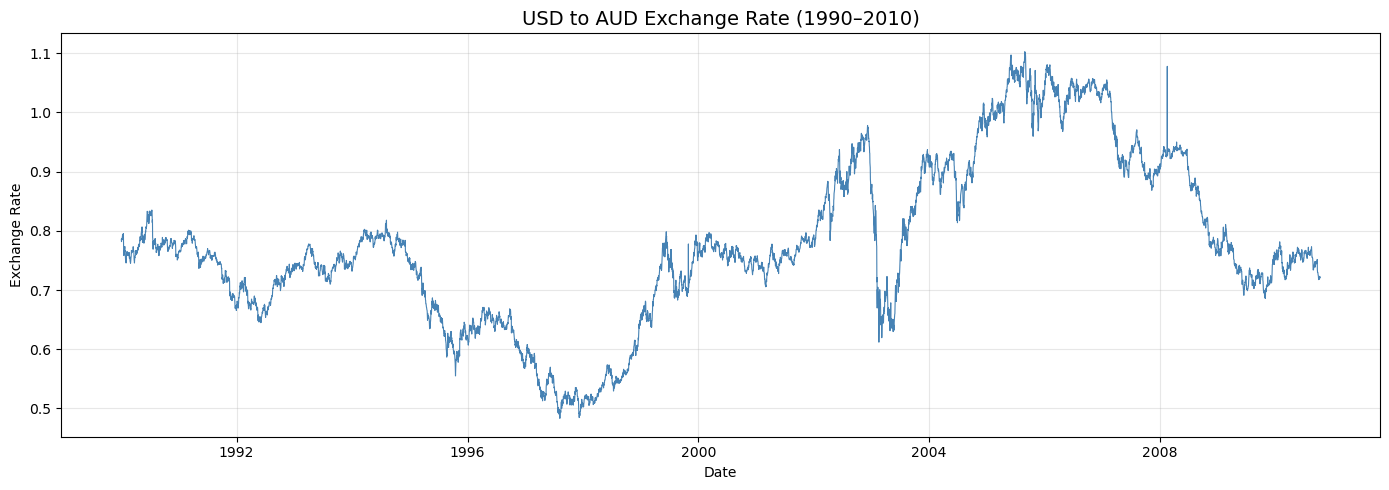

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(df['Ex_rate'], color='steelblue', linewidth=0.8)
plt.title('USD to AUD Exchange Rate (1990–2010)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Check for missing values
print("Missing values:", df.isnull().sum().values[0])

# Fill any gaps using forward fill (common for financial time series)
df['Ex_rate'] = df['Ex_rate'].ffill()

# Detect anomalies using IQR
Q1 = df['Ex_rate'].quantile(0.25)
Q3 = df['Ex_rate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

anomalies = df[(df['Ex_rate'] < lower) | (df['Ex_rate'] > upper)]
print(f"\nAnomalies detected: {len(anomalies)}")
print(anomalies)

# If anomalies exist, replace with interpolated values
df['Ex_rate'] = df['Ex_rate'].clip(lower=lower, upper=upper)

print("\nPreprocessing complete.")

Missing values: 0

Anomalies detected: 0
Empty DataFrame
Columns: [Ex_rate]
Index: []

Preprocessing complete.


In [21]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Conclusion    : {'Stationary ✅' if result[1] < 0.05 else 'Non-stationary ❌'}")
    print()

adf_test(df['Ex_rate'], 'Original Exchange Rate')

# If non-stationary, difference the series
df['Ex_rate_diff'] = df['Ex_rate'].diff()
adf_test(df['Ex_rate_diff'].dropna(), '1st Order Differenced')

--- ADF Test: Original Exchange Rate ---
ADF Statistic : -1.6650
p-value       : 0.4492
Conclusion    : Non-stationary ❌

--- ADF Test: 1st Order Differenced ---
ADF Statistic : -99.3934
p-value       : 0.0000
Conclusion    : Stationary ✅



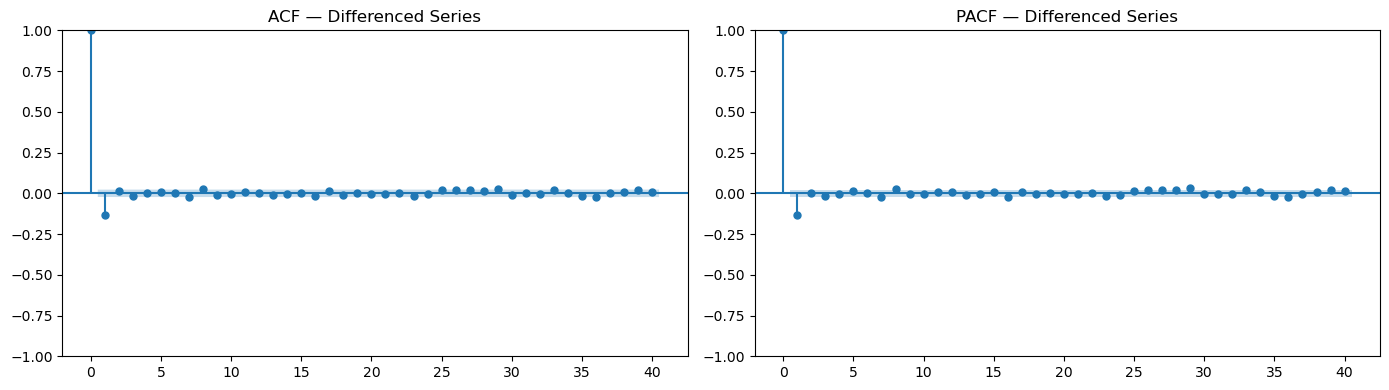

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['Ex_rate_diff'].dropna(), lags=40, ax=axes[0], title='ACF — Differenced Series')
plot_pacf(df['Ex_rate_diff'].dropna(), lags=40, ax=axes[1], title='PACF — Differenced Series')

plt.tight_layout()
plt.show()

In [23]:
# Use last 180 days as test set
train_size = len(df) - 180
train = df['Ex_rate'].iloc[:train_size]
test  = df['Ex_rate'].iloc[train_size:]

print(f"Training samples : {len(train)}")
print(f"Test samples     : {len(test)}")

Training samples : 7408
Test samples     : 180


In [24]:
# Based on ACF/PACF — try ARIMA(1,1,1) as a starting point
# Adjust (p,d,q) based on your ACF/PACF analysis
p, d, q = 1, 1, 1

arima_model = ARIMA(train, order=(p, d, q))
arima_fit   = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7408
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27334.640
Date:                Thu, 04 Jun 2026   AIC                         -54663.280
Time:                        15:59:54   BIC                         -54642.549
Sample:                    01-01-1990   HQIC                        -54656.156
                         - 04-13-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1229      0.046     -2.683      0.007      -0.213      -0.033
ma.L1         -0.0093      0.046     -0.202      0.840      -0.099       0.081
sigma2      3.648e-05   1.02e-07    356.344      0.0

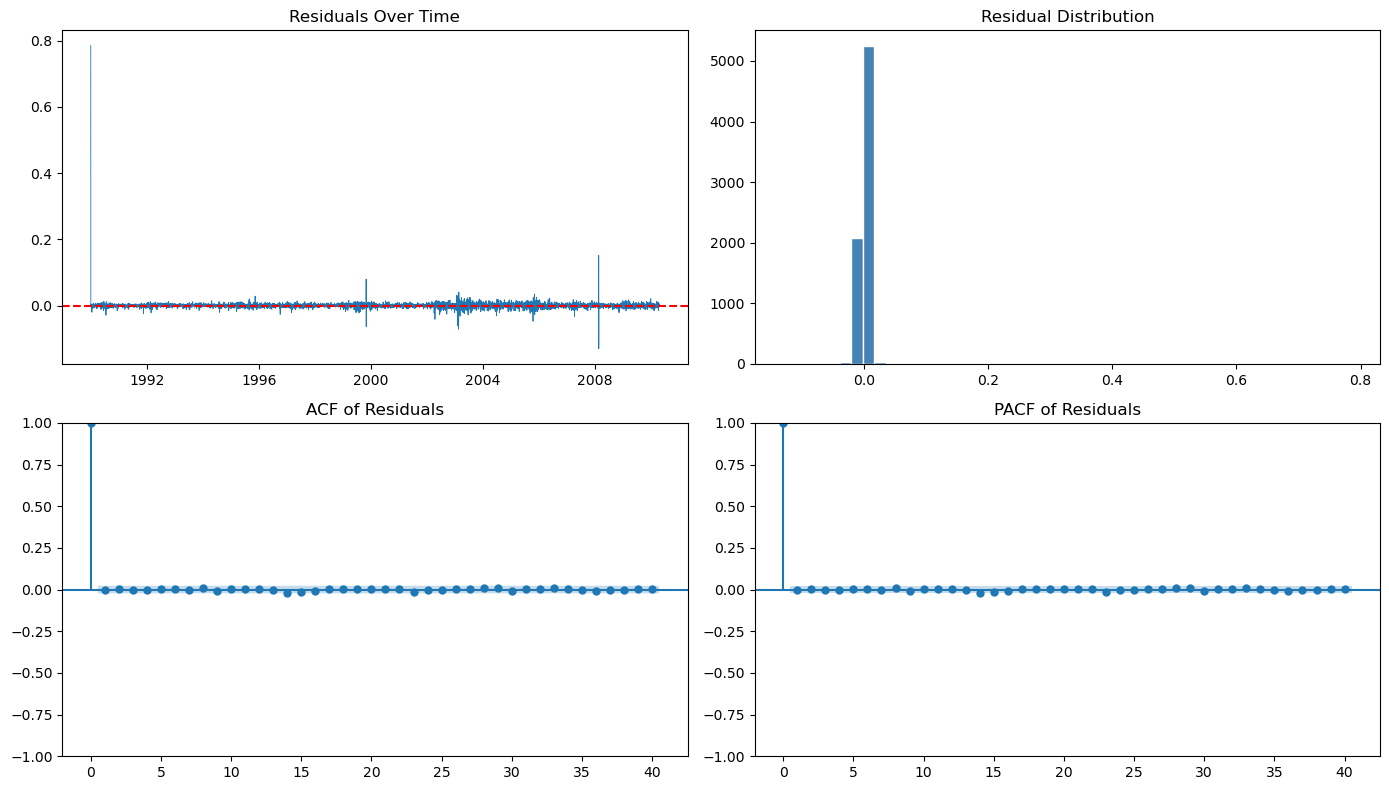

Mean of residuals: 0.000101  (should be ≈ 0)


In [25]:
residuals = arima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residual plot
axes[0, 0].plot(residuals, linewidth=0.6)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].axhline(0, color='red', linestyle='--')

# Histogram
axes[0, 1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Residual Distribution')

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 0], title='ACF of Residuals')

# PACF of residuals
plot_pacf(residuals, lags=40, ax=axes[1, 1], title='PACF of Residuals')

plt.tight_layout()
plt.show()

print(f"Mean of residuals: {residuals.mean():.6f}  (should be ≈ 0)")

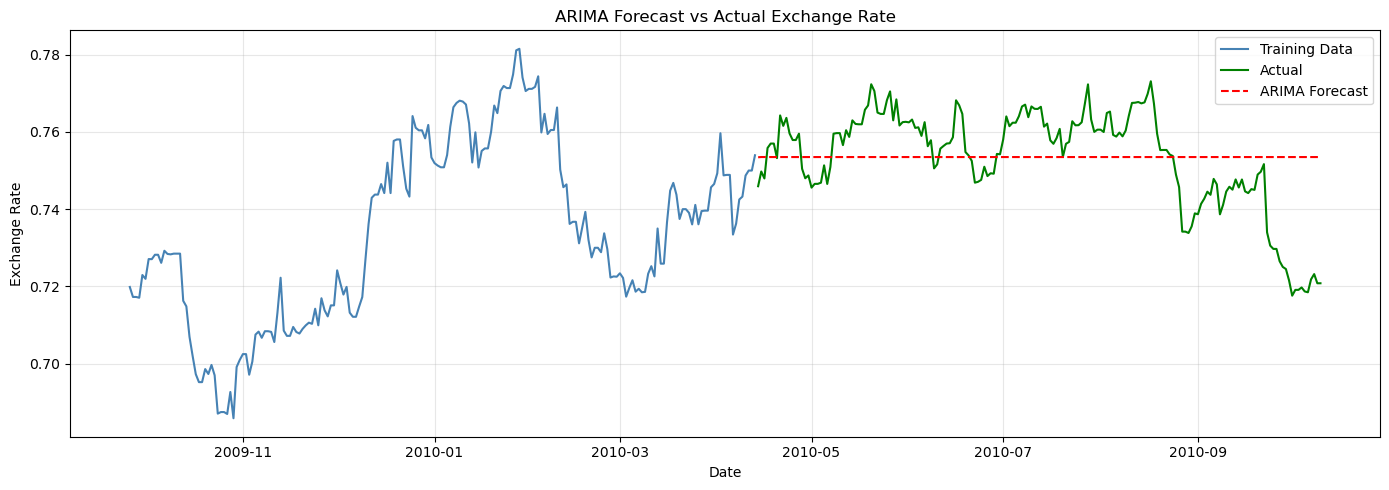

In [26]:
# Forecast for test period
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train[-200:], label='Training Data', color='steelblue')
plt.plot(test,          label='Actual',        color='green')
plt.plot(arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast vs Actual Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7408
Model:             ExponentialSmoothing   SSE                              0.270
Optimized:                         True   AIC                         -75691.221
Trend:                         Additive   BIC                         -75663.580
Seasonal:                          None   AICC                        -75691.210
Seasonal Periods:                  None   Date:                 Thu, 04 Jun 2026
Box-Cox:                          False   Time:                         16:00:19
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8692352                alpha                 True
smoothing_trend             0.0000

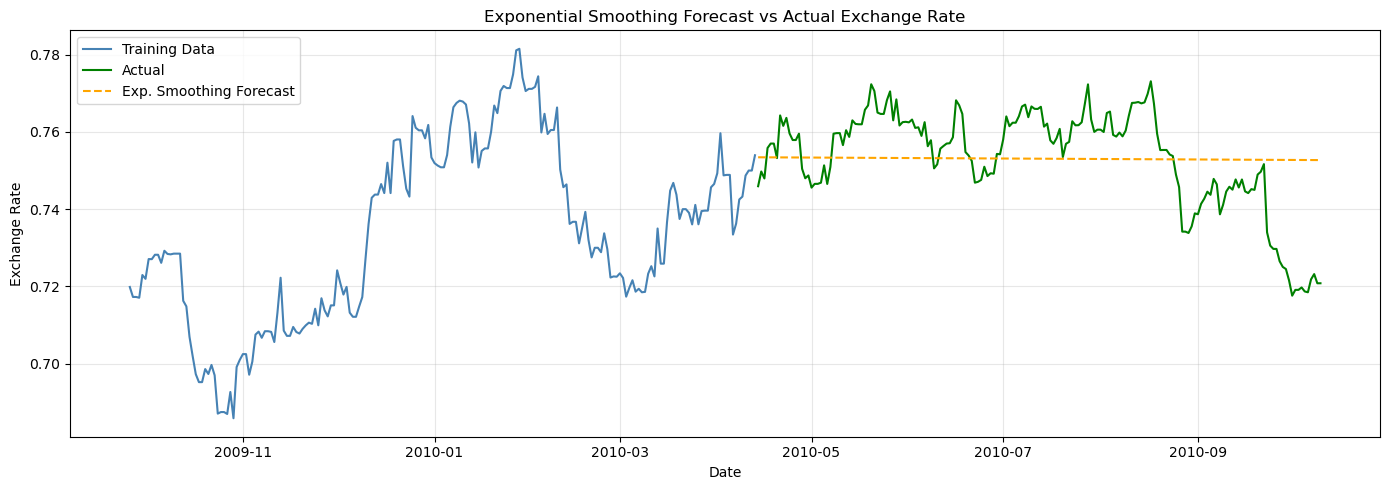

In [27]:
# Holt's Linear model (no seasonality — daily financial data typically has none)
es_model = ExponentialSmoothing(
    train,
    trend='add',       # additive trend
    seasonal=None      # no seasonal component
)
es_fit = es_model.fit(optimized=True)
print(es_fit.summary())

# Forecast
es_forecast = es_fit.forecast(steps=len(test))
es_forecast = pd.Series(es_forecast.values, index=test.index)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train[-200:],  label='Training Data',         color='steelblue')
plt.plot(test,           label='Actual',                color='green')
plt.plot(es_forecast,    label='Exp. Smoothing Forecast', color='orange', linestyle='--')
plt.title("Exponential Smoothing Forecast vs Actual Exchange Rate")
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
def evaluate_model(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"--- {model_name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print()
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []
results.append(evaluate_model(test, arima_forecast, 'ARIMA'))
results.append(evaluate_model(test, es_forecast,    'Exponential Smoothing'))

# Summary table
results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

--- ARIMA ---
MAE  : 0.0103
RMSE : 0.0130
MAPE : 1.37%

--- Exponential Smoothing ---
MAE  : 0.0103
RMSE : 0.0129
MAPE : 1.37%

                            MAE      RMSE      MAPE
Model                                              
ARIMA                  0.010257  0.013046  1.373045
Exponential Smoothing  0.010263  0.012930  1.372923


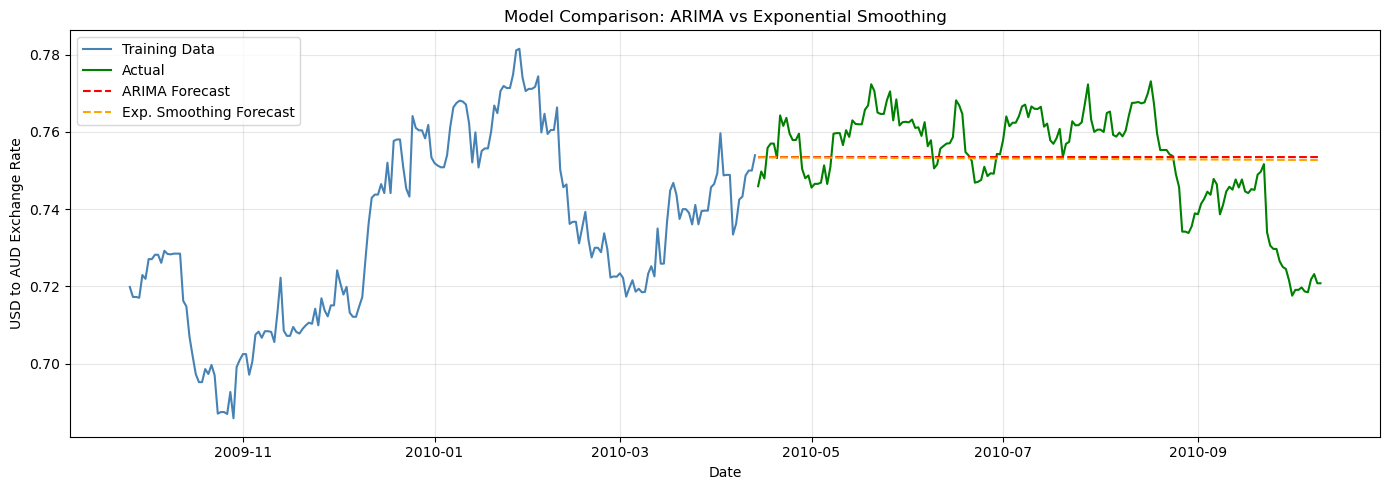

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(train[-200:],  label='Training Data',              color='steelblue')
plt.plot(test,           label='Actual',                     color='green', linewidth=1.5)
plt.plot(arima_forecast, label='ARIMA Forecast',             color='red',    linestyle='--')
plt.plot(es_forecast,    label='Exp. Smoothing Forecast',    color='orange', linestyle='--')
plt.title('Model Comparison: ARIMA vs Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('USD to AUD Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
print("""
CONCLUSION
==========
- ARIMA(p,d,q) captured short-term autocorrelation in the exchange rate.
- Exponential Smoothing tracked the trend component smoothly.

Error Summary:
""")
print(results_df.to_string())
print("""
- Lower MAE/RMSE/MAPE indicates a better model.
- ARIMA is better when the series shows strong autocorrelation (ACF/PACF patterns).
- Exponential Smoothing is better for series with a clear trend and no strong lag structure.
- Both models assume a single trend direction over the forecast horizon,
  which may cause divergence for long-range forecasts.
""")


CONCLUSION
- ARIMA(p,d,q) captured short-term autocorrelation in the exchange rate.
- Exponential Smoothing tracked the trend component smoothly.

Error Summary:

                            MAE      RMSE      MAPE
Model                                              
ARIMA                  0.010257  0.013046  1.373045
Exponential Smoothing  0.010263  0.012930  1.372923

- Lower MAE/RMSE/MAPE indicates a better model.
- ARIMA is better when the series shows strong autocorrelation (ACF/PACF patterns).
- Exponential Smoothing is better for series with a clear trend and no strong lag structure.
- Both models assume a single trend direction over the forecast horizon,
  which may cause divergence for long-range forecasts.

